# Forecasting PV Production -- TSMixer vs PatchTST + SHAP & LIME

In [ ]:
import subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import lime.lime_tabular
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, "../model")
from tsmixer_wind import TSMixer, train_tsmixer, evaluate

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

LOOKBACK   = 48   # hours of historical context
HORIZON    = 24   # hours to predict
BATCH_SIZE = 32
MAX_EPOCHS = 100
MIN_EPOCHS = 30    # never stop before this, regardless of val loss
PATIENCE   = 20   # bumped up: ReduceLROnPlateau patience=5 inside train_tsmixer was halving LR aggressively
LR         = 1e-3

# Priority: CUDA (Nvidia) > MPS (Apple Silicon GPU) > CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"


XAI_DEVICE = "cpu" 

print(f"PyTorch {torch.__version__} | Training device: {DEVICE} | XAI device: {XAI_DEVICE}")

PyTorch 2.11.0 | Training device: mps | XAI device: cpu


---
## 1. Data loading & feature selection

In [25]:
DATA_DIR = "../dane_merged"
TARGET   = "PV_MWh"

train_df = pd.read_csv(f"{DATA_DIR}/dataset_train.csv", parse_dates=["Date"])
val_df   = pd.read_csv(f"{DATA_DIR}/dataset_val.csv",   parse_dates=["Date"])

# Use ALL available features (every column except the date index and target)
# This includes:
#   144 province-level features  (16 provinces × 9 variables:
#       Avg_Air_Temp, Rel_Air_Humidity, Rainfall, Snowfall,
#       Avg_Soil_Temp, Soil_Humidity, Wind_Speed, Dew_Point, Solar_Radiation)
#    18 national aggregates (PL_mean_* and PL_std_* across all provinces)
#    15 temporal features (raw integers + cyclic sin/cos + binary flags)
NON_FEATURE = {"Date", TARGET}
MODEL_FEATURES = sorted([c for c in train_df.columns if c not in NON_FEATURE])

# Interpretable subset kept for SHAP plots and LIME explanations
# (SHAP runs on all features but the bar chart shows only top-N;
#  LIME uses this reduced set so its surrogate model stays stable)
PL_FEATS   = [c for c in MODEL_FEATURES if c.startswith("PL_")]
TIME_FEATS = [c for c in MODEL_FEATURES
              if any(c.startswith(p) for p in ["hour", "day", "month", "week", "is_"])]
PROV_SOLAR = [c for c in MODEL_FEATURES if c.endswith("_Solar_Radiation")]
INTERP_FEATURES = sorted(set(PL_FEATS + TIME_FEATS + PROV_SOLAR))  # for LIME
SHAP_TOP_N = 25   # how many features to show in SHAP bar/beeswarm plots

prov_feats = [c for c in MODEL_FEATURES if c not in PL_FEATS and c not in TIME_FEATS]
print(f"Total model features : {len(MODEL_FEATURES)}")
print(f"  Province-level     : {len(prov_feats)}  (16 provinces × 9 variables)")
print(f"  PL aggregates      : {len(PL_FEATS)}")
print(f"  Temporal           : {len(TIME_FEATS)}")
print(f"Interpretable subset : {len(INTERP_FEATURES)}  (used for LIME; SHAP shows top-{SHAP_TOP_N})")
print(f"Train rows: {len(train_df):,}  |  Val rows: {len(val_df):,}")

Total model features : 177
  Province-level     : 145  (16 provinces × 9 variables)
  PL aggregates      : 18
  Temporal           : 14
Interpretable subset : 48  (used for LIME; SHAP shows top-25)
Train rows: 10,684  |  Val rows: 169


---
## 2. Scaling and sliding-window sequences

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_arr = scaler_X.fit_transform(train_df[MODEL_FEATURES].values.astype("float32"))
y_train_arr = scaler_y.fit_transform(train_df[[TARGET]].values.astype("float32"))
X_val_arr   = scaler_X.transform(val_df[MODEL_FEATURES].values.astype("float32"))
y_val_arr   = scaler_y.transform(val_df[[TARGET]].values.astype("float32"))

def make_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype="float32"), np.array(ys, dtype="float32")

X_train_seq, y_train_seq = make_sequences(X_train_arr, y_train_arr, LOOKBACK, HORIZON)

ctx_X = np.vstack([X_train_arr[-LOOKBACK:], X_val_arr])
ctx_y = np.vstack([y_train_arr[-LOOKBACK:], y_val_arr])
X_val_seq, y_val_seq = make_sequences(ctx_X, ctx_y, LOOKBACK, HORIZON)

ISPLIT = 500
X_nn_tr, y_nn_tr = X_train_seq[:-ISPLIT], y_train_seq[:-ISPLIT]
X_nn_vl, y_nn_vl = X_train_seq[-ISPLIT:], y_train_seq[-ISPLIT:]

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

loader_tr  = make_loader(X_nn_tr, y_nn_tr, shuffle=True)
loader_vl  = make_loader(X_nn_vl, y_nn_vl)
loader_val = make_loader(X_val_seq, y_val_seq)

N_FEATURES = X_train_seq.shape[2]
n_seq      = len(X_val_seq)
print(f"X_train : {X_train_seq.shape}  y_train : {y_train_seq.shape}")
print(f"X_val   : {X_val_seq.shape}  y_val   : {y_val_seq.shape}")
print(f"N_FEATURES = {N_FEATURES}")

X_train : (10613, 48, 177)  y_train : (10613, 24)
X_val   : (146, 48, 177)  y_val   : (146, 24)
N_FEATURES = 177


In [27]:
def train_model(model, train_loader, val_loader,
                epochs=100, min_epochs=30, lr=1e-3,
                weight_decay=1e-4, patience=20, device=DEVICE):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Cosine annealing: LR smoothly decays from lr -> 0 over T_max epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    criterion = nn.MSELoss()

    best_val, best_state, patience_counter = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                val_losses.append(criterion(model(X_b.to(device)), y_b.to(device)).item())

        tl, vl = float(np.mean(train_losses)), float(np.mean(val_losses))
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:4d} | train={tl:.4f}  val={vl:.4f}'
                  f'  lr={optimizer.param_groups[0]["lr"]:.2e}')

        if vl < best_val - 1e-4:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        elif epoch >= min_epochs:   # patience only active after min_epochs
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}. Best val: {best_val:.4f}')
                break

    if best_state:
        model.load_state_dict(best_state)
    return history


## 2. Model 1 -- TSMixer
TSMixer: An All-MLP Architecture for Time Series Forecasting - https://arxiv.org/abs/2303.06053

In [28]:
# With 177 features the feature-mixing MLP is 177→(177*expansion)→177 per block.
# n_blocks=2, expansion=2 keeps TSMixer at ~460k params — reasonable for 10k sequences.
tsmixer = TSMixer(
    seq_len    = LOOKBACK,
    horizon    = HORIZON,
    n_features = N_FEATURES,
    n_blocks   = 2,
    expansion  = 2,
    dropout    = 0.2,   # slightly higher dropout with more features
).to(DEVICE)

n_params_ts = sum(p.numel() for p in tsmixer.parameters() if p.requires_grad)
print(f"TSMixer trainable parameters: {n_params_ts:,}")

TSMixer trainable parameters: 461,742


In [29]:
print("Training TSMixer...")
history_ts = train_model(
    tsmixer, loader_tr, loader_vl,
    epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS,
    lr=LR, weight_decay=1e-4,
    patience=PATIENCE, device=DEVICE,
)

Training TSMixer...
Epoch    1 | train=0.3175  val=0.3042  lr=1.00e-03
Epoch   10 | train=0.2741  val=0.3982  lr=9.76e-04
Epoch   20 | train=0.2003  val=0.4334  lr=9.05e-04
Epoch   30 | train=0.0844  val=0.3041  lr=7.96e-04
Epoch   40 | train=0.1898  val=0.2726  lr=6.58e-04
Early stopping at epoch 49. Best val: 0.1898



───────────────────────────────────
  MAE  : 1472.5702
  RMSE : 1971.1372
  MAPE : 480.67%
───────────────────────────────────



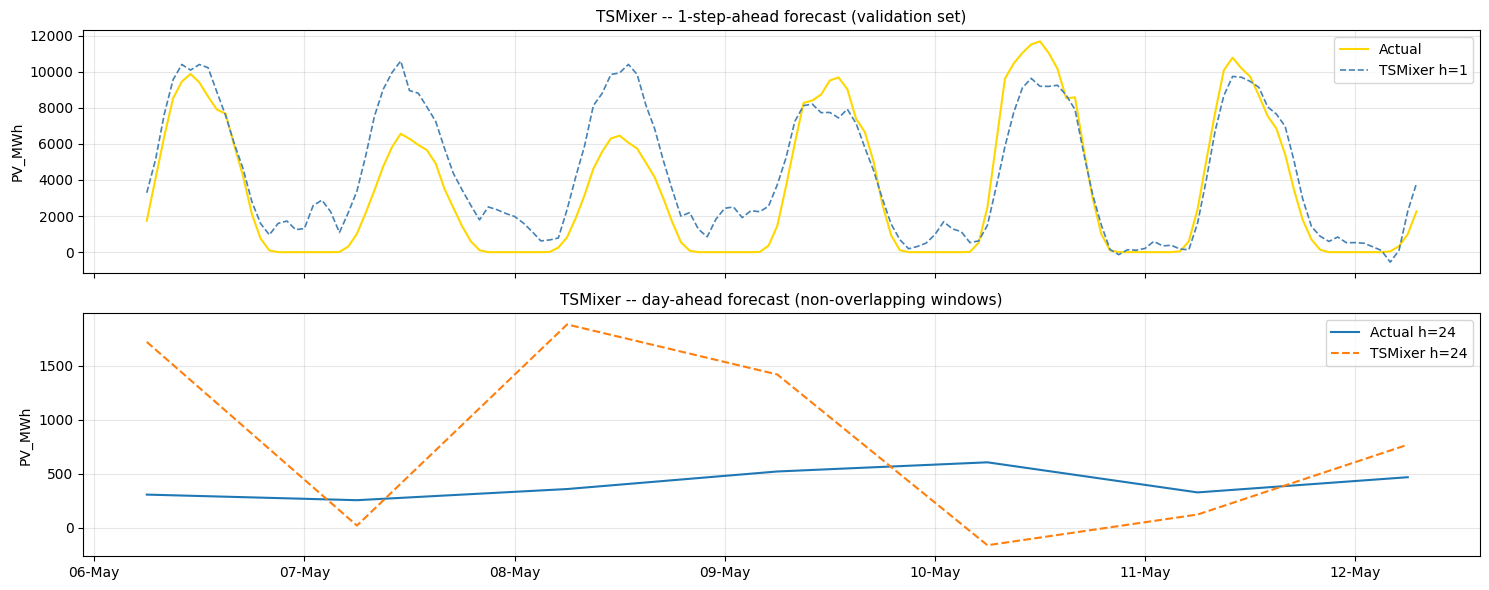

TSMixer  |  MAE=1472.57  RMSE=1971.14  MAPE=480.7%


In [30]:
preds_ts, trues_ts, metrics_ts = evaluate(tsmixer, loader_val, scaler_y=scaler_y, device=DEVICE)

plot_dates = val_df["Date"].values[:n_seq]

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(plot_dates, trues_ts[:, 0], color="gold",     lw=1.5, label="Actual")
axes[0].plot(plot_dates, preds_ts[:, 0], color="steelblue", lw=1.2, ls="--", label="TSMixer h=1")
axes[0].set_title("TSMixer -- 1-step-ahead forecast (validation set)", fontsize=11)
axes[0].set_ylabel("PV_MWh"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(plot_dates[::HORIZON], trues_ts[::HORIZON, -1], label="Actual h=24")
axes[1].plot(plot_dates[::HORIZON], preds_ts[::HORIZON, -1], ls="--", label="TSMixer h=24")
axes[1].set_title("TSMixer -- day-ahead forecast (non-overlapping windows)", fontsize=11)
axes[1].set_ylabel("PV_MWh"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout(); plt.show()

rmse_ts = np.sqrt(mean_squared_error(trues_ts.flatten(), preds_ts.flatten()))
print(f"TSMixer  |  MAE={metrics_ts['mae']:.2f}  RMSE={rmse_ts:.2f}  MAPE={metrics_ts['mape']:.1f}%")

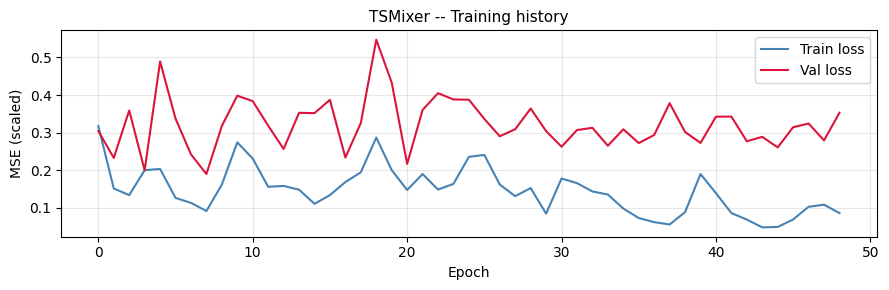

In [31]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history_ts["train_loss"], label="Train loss", color="steelblue")
ax.plot(history_ts["val_loss"],   label="Val loss",   color="crimson")
ax.set_title("TSMixer -- Training history", fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Model 2 -- PatchTST (Transformer)
A Time Series is Worth 64 Words - https://arxiv.org/abs/2211.14730

In [32]:
class PatchEmbedding(nn.Module):
    # Linear projection of each (patch_len x n_features) patch into d_model space
    def __init__(self, n_features, patch_len, d_model, dropout=0.1):
        super().__init__()
        self.patch_len = patch_len
        self.proj      = nn.Linear(patch_len * n_features, d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, F)
        B, T, F = x.shape
        n_patches = T // self.patch_len
        x = x[:, : n_patches * self.patch_len, :]
        x = x.reshape(B, n_patches, self.patch_len * F)
        return self.dropout(self.proj(x))   # (B, n_patches, d_model)


class PatchTST(nn.Module):
    # Channel-mixing PatchTST: multivariate -> univariate forecasting
    def __init__(self, seq_len, horizon, n_features,
                 patch_len=8, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        assert seq_len % patch_len == 0
        self.n_patches   = seq_len // patch_len
        self.patch_embed = PatchEmbedding(n_features, patch_len, d_model, dropout)

        # Learnable positional embeddings (one per patch token)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(self.n_patches * d_model, horizon)

    def forward(self, x):
        x = self.patch_embed(x)       # (B, n_patches, d_model)
        x = x + self.pos_embed
        x = self.transformer(x)
        x = self.norm(x)
        return self.head(x.flatten(1))  # (B, horizon)

In [33]:
patchtst = PatchTST(
    seq_len    = LOOKBACK,   # 48
    horizon    = HORIZON,    # 24
    n_features = N_FEATURES,
    patch_len  = 8,          # 48 / 8 = 6 patch tokens
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    dropout    = 0.1,
).to(DEVICE)

n_params_pt = sum(p.numel() for p in patchtst.parameters() if p.requires_grad)
print(f"PatchTST trainable parameters: {n_params_pt:,}")

print("Training PatchTST...")
history_pt = train_model(
    patchtst, loader_tr, loader_vl,
    epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS,
    lr=LR, weight_decay=1e-4,
    patience=PATIENCE, device=DEVICE,
)

PatchTST trainable parameters: 200,408
Training PatchTST...
Epoch    1 | train=0.1237  val=0.1952  lr=1.00e-03
Epoch   10 | train=0.0220  val=0.2425  lr=9.76e-04
Epoch   20 | train=0.0146  val=0.2569  lr=9.05e-04
Epoch   30 | train=0.0125  val=0.2713  lr=7.96e-04
Epoch   40 | train=0.0089  val=0.2892  lr=6.58e-04
Early stopping at epoch 49. Best val: 0.1733



───────────────────────────────────
  MAE  : 945.1838
  RMSE : 1436.8146
  MAPE : 104.80%
───────────────────────────────────



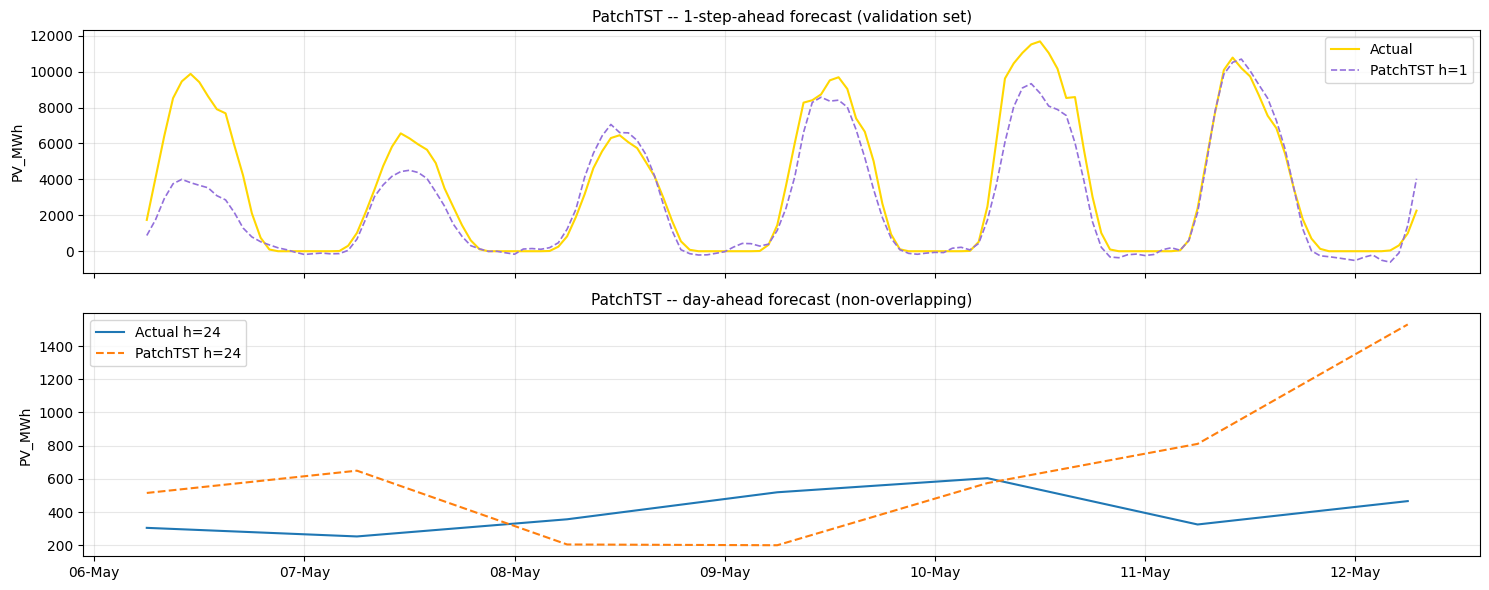

PatchTST |  MAE=945.18  RMSE=1436.81  MAPE=104.8%


In [35]:
preds_pt, trues_pt, metrics_pt = evaluate(patchtst, loader_val, scaler_y=scaler_y, device=DEVICE)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(plot_dates, trues_pt[:, 0], color="gold",         lw=1.5, label="Actual")
axes[0].plot(plot_dates, preds_pt[:, 0], color="mediumpurple", lw=1.2, ls="--", label="PatchTST h=1")
axes[0].set_title("PatchTST -- 1-step-ahead forecast (validation set)", fontsize=11)
axes[0].set_ylabel("PV_MWh"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(plot_dates[::HORIZON], trues_pt[::HORIZON, -1], label="Actual h=24")
axes[1].plot(plot_dates[::HORIZON], preds_pt[::HORIZON, -1], ls="--", label="PatchTST h=24")
axes[1].set_title("PatchTST -- day-ahead forecast (non-overlapping)", fontsize=11)
axes[1].set_ylabel("PV_MWh"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout(); plt.show()

rmse_pt = np.sqrt(mean_squared_error(trues_pt.flatten(), preds_pt.flatten()))
print(f"PatchTST |  MAE={metrics_pt['mae']:.2f}  RMSE={rmse_pt:.2f}  MAPE={metrics_pt['mape']:.1f}%")

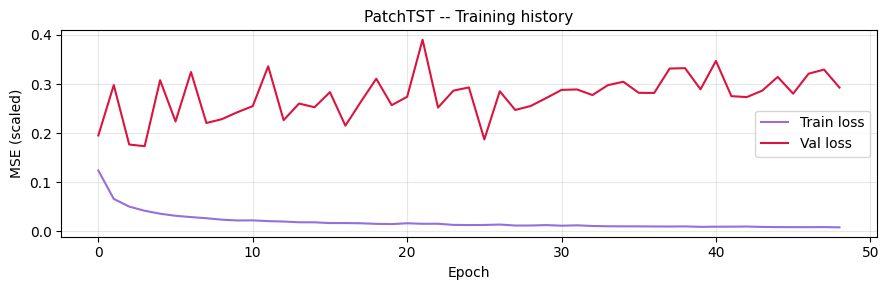

In [36]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history_pt["train_loss"], label="Train loss", color="mediumpurple")
ax.plot(history_pt["val_loss"],   label="Val loss",   color="crimson")
ax.set_title("PatchTST -- Training history", fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [37]:
NIGHT_THRESH = 50   # MWh: hours below this are treated as 'night' for daytime metrics

def compute_metrics(y_true, y_pred, name='Model',
                    naive_mae=None, seasonal_naive_mae=None):
    y_true, y_pred = y_true.flatten(), y_pred.flatten()
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-6)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-9)

    mask = y_true > NIGHT_THRESH
    mae_day  = np.mean(np.abs(y_true[mask] - y_pred[mask])) if mask.sum() > 0 else np.nan
    mape_day = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    r2_day   = (1 - np.sum((y_true[mask]-y_pred[mask])**2) / (np.sum((y_true[mask]-y_true[mask].mean())**2)+1e-9))\
               if mask.sum() > 1 else np.nan

    skill = (1 - mae / naive_mae) if naive_mae else np.nan

    mase  = (mae / seasonal_naive_mae) if seasonal_naive_mae else np.nan

    n_days = len(y_true) // HORIZON
    if n_days > 0:
        y24  = y_true[:n_days*HORIZON].reshape(n_days, HORIZON).sum(axis=1)
        p24  = y_pred[:n_days*HORIZON].reshape(n_days, HORIZON).sum(axis=1)
        daily_err = np.mean(np.abs(y24 - p24) / (y24 + 1e-6)) * 100
    else:
        daily_err = np.nan

    return {
        'Model':         name,
        'MAE':           round(mae, 1),
        'RMSE':          round(rmse, 1),
        'sMAPE (%)':     round(smape, 1),
        'R2':            round(r2, 4),
        'Skill Score':   round(skill, 4) if not np.isnan(skill) else 'N/A',
        'MASE':          round(mase, 4)  if not np.isnan(mase)  else 'N/A',
        'MAE daytime':   round(mae_day, 1),
        'MAPE day (%)':  round(mape_day, 1),
        'R2 daytime':    round(r2_day, 4),
        'Daily err (%)': round(daily_err, 1),
    }

In [38]:
persist_preds = np.zeros_like(trues_ts)
for k in range(len(trues_ts)):
    last_known = scaler_y.inverse_transform([[ctx_y[k + LOOKBACK - 1, 0]]])[0, 0]
    persist_preds[k] = last_known

persist_mae = np.mean(np.abs(trues_ts.flatten() - persist_preds.flatten()))

SEASON_LAG = 7 * 24
if LOOKBACK >= SEASON_LAG:
    sn_preds = np.zeros_like(trues_ts)
    ctx_y_inv = scaler_y.inverse_transform(ctx_y)[:, 0]
    for k in range(len(trues_ts)):
        for h in range(HORIZON):
            hist_idx = k + LOOKBACK + h - SEASON_LAG
            sn_preds[k, h] = ctx_y_inv[hist_idx] if hist_idx >= 0 else 0.0
    sn_mae = np.mean(np.abs(trues_ts.flatten() - sn_preds.flatten()))
else:
    sn_mae = persist_mae

print(f'Baseline: persistence MAE       = {persist_mae:.1f} MWh')
print(f'Baseline: seasonal naive MAE    = {sn_mae:.1f} MWh  (same hour, 7 days ago)')


Baseline: persistence MAE       = 3863.2 MWh
Baseline: seasonal naive MAE    = 3863.2 MWh  (same hour, 7 days ago)


In [40]:
rows = []
for model_name, preds_arr in [
    ('Persistence',    persist_preds),
    ('TSMixer',        preds_ts),
    ('PatchTST',       preds_pt),
]:
    rows.append(compute_metrics(
        trues_ts, preds_arr,
        name              = model_name,
        naive_mae         = persist_mae,
        seasonal_naive_mae = sn_mae,
    ))

metrics_df = pd.DataFrame(rows)
metrics_df

,Model,MAE,RMSE,sMAPE (%),R2,Skill Score,MASE,MAE daytime,MAPE day (%),R2 daytime,Daily err (%)
0,Persistence,3863.199951,5079.000000,151.000000,-0.9663,0.0000,1.0000,4114.299805,356.000000,-1.2416,100.300003
1,TSMixer,1472.599976,1971.099976,100.599998,0.7038,0.6188,0.3812,1801.599976,113.699997,0.5510,34.400002
2,PatchTST,945.200012,1436.800049,97.699997,0.8426,0.7553,0.2447,1319.300049,46.799999,0.7375,25.299999


In [41]:
best_model = tsmixer if float(metrics_df.loc[metrics_df['Model']=='TSMixer','MAE'].values[0]) \
                     <= float(metrics_df.loc[metrics_df['Model']=='PatchTST','MAE'].values[0]) \
             else patchtst
best_name = 'TSMixer' if float(metrics_df.loc[metrics_df['Model']=='TSMixer','MAE'].values[0]) \
                      <= float(metrics_df.loc[metrics_df['Model']=='PatchTST','MAE'].values[0]) \
            else 'PatchTST'
print(f'\nBest model for SHAP/LIME: {best_name}')


Best model for SHAP/LIME: PatchTST


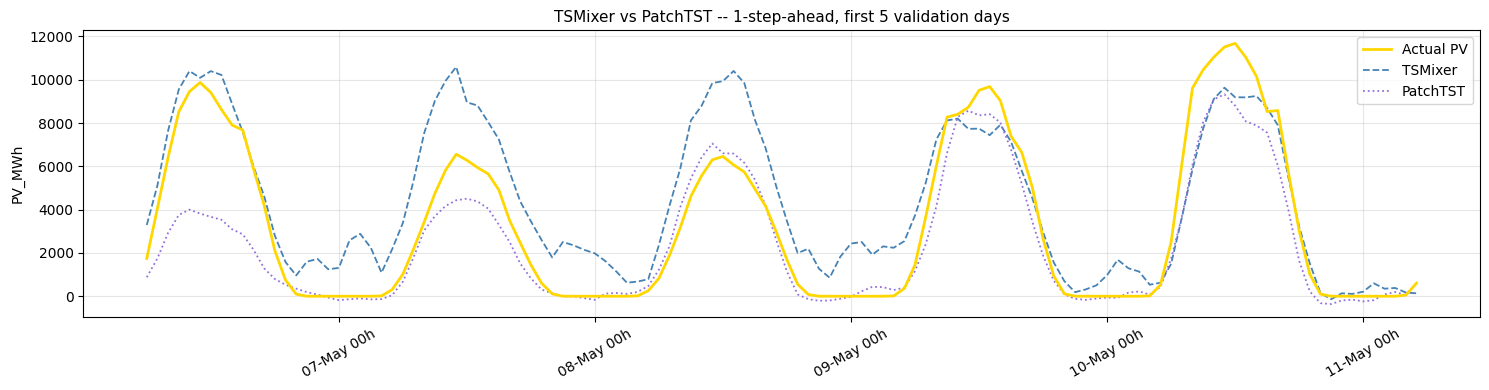

In [42]:
N_PLOT = min(5 * 24, n_seq)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(plot_dates[:N_PLOT], trues_ts[:N_PLOT, 0],
        color="gold", lw=2.0, label="Actual PV", zorder=3)
ax.plot(plot_dates[:N_PLOT], preds_ts[:N_PLOT, 0],
        color="steelblue", lw=1.3, ls="--", label="TSMixer", zorder=2)
ax.plot(plot_dates[:N_PLOT], preds_pt[:N_PLOT, 0],
        color="mediumpurple", lw=1.3, ls=":", label="PatchTST", zorder=2)
ax.set_title("TSMixer vs PatchTST -- 1-step-ahead, first 5 validation days", fontsize=11)
ax.set_ylabel("PV_MWh"); ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

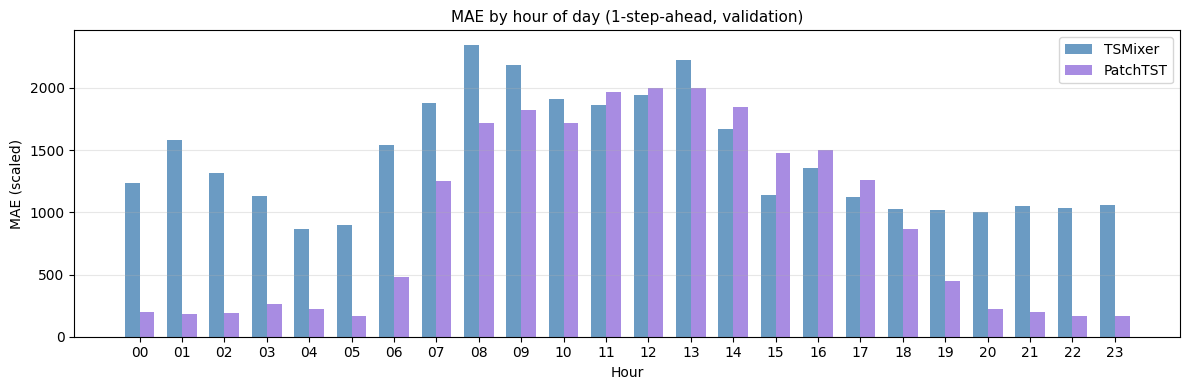

In [43]:
def hourly_mae(trues, preds, val_df, n_seq):
    actual_hours = val_df["hour"].values[:n_seq]
    return {h: np.mean(np.abs(trues[actual_hours == h, 0] - preds[actual_hours == h, 0]))
            for h in range(24) if (actual_hours == h).sum() > 0}

mae_h_ts = hourly_mae(trues_ts, preds_ts, val_df, n_seq)
mae_h_pt = hourly_mae(trues_pt, preds_pt, val_df, n_seq)
hours = sorted(mae_h_ts.keys())
x = np.arange(len(hours)); w = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, [mae_h_ts[h] for h in hours], w, color="steelblue",    alpha=0.8, label="TSMixer")
ax.bar(x + w/2, [mae_h_pt[h] for h in hours], w, color="mediumpurple", alpha=0.8, label="PatchTST")
ax.set_xticks(x); ax.set_xticklabels([f"{h:02d}" for h in hours])
ax.set_title("MAE by hour of day (1-step-ahead, validation)", fontsize=11)
ax.set_xlabel("Hour"); ax.set_ylabel("MAE (scaled)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 5. Feature importance -- SHAP (GradientExplainer)

In [44]:
class ScalarWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).sum(dim=1, keepdim=True)   # (B, 1)

best_model.eval()
# SHAP GradientExplainer relies on torch.autograd hooks not yet fully supported on MPS.
# Move the model temporarily to XAI_DEVICE (CPU) for SHAP, then move back for inference.
scalar_model = ScalarWrapper(best_model).to(XAI_DEVICE)

rng    = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_nn_tr), 150, replace=False)
background = torch.FloatTensor(X_nn_tr[bg_idx]).to(XAI_DEVICE)

test_seqs = torch.FloatTensor(X_val_seq[:60]).to(XAI_DEVICE)

print(f"Computing SHAP values (GradientExplainer on {XAI_DEVICE}) ...")
shap_explainer = shap.GradientExplainer(scalar_model, background)
shap_raw = shap_explainer.shap_values(test_seqs)
shap_vals = np.array(shap_raw[0]) if isinstance(shap_raw, list) else np.array(shap_raw)
if shap_vals.ndim == 4 and shap_vals.shape[-1] == 1:
    shap_vals = shap_vals.squeeze(-1)   # (n, LOOKBACK, N_FEATURES)
print(f"SHAP values shape: {shap_vals.shape}  (expected: (60, {LOOKBACK}, N_FEATURES))")

Computing SHAP values (GradientExplainer on cpu) ...
SHAP values shape: (60, 48, 177)  (expected: (60, 48, N_FEATURES))


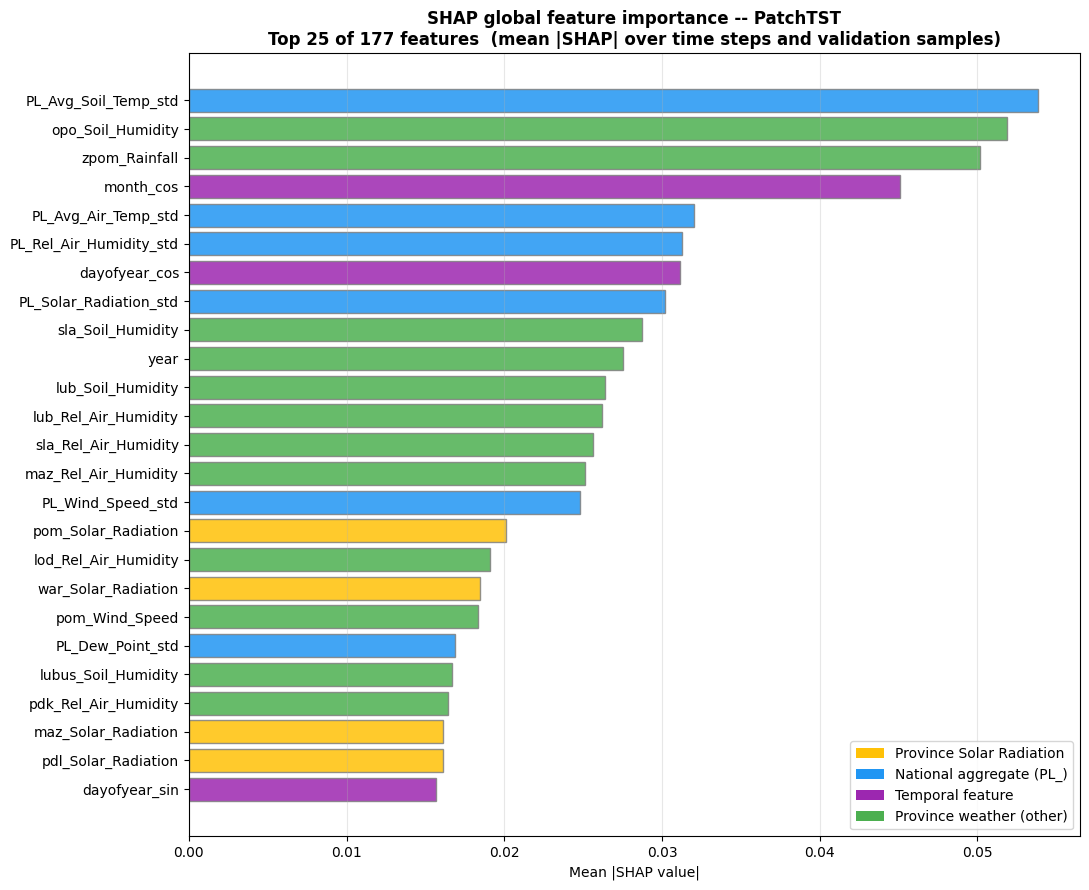

Top 15 of 177 features by SHAP importance:
                feature  shap_importance
   PL_Avg_Soil_Temp_std         0.053810
      opo_Soil_Humidity         0.051849
          zpom_Rainfall         0.050131
              month_cos         0.045059
    PL_Avg_Air_Temp_std         0.032002
PL_Rel_Air_Humidity_std         0.031264
          dayofyear_cos         0.031162
 PL_Solar_Radiation_std         0.030177
      sla_Soil_Humidity         0.028739
                   year         0.027533
      lub_Soil_Humidity         0.026415
   lub_Rel_Air_Humidity         0.026219
   sla_Rel_Air_Humidity         0.025652
   maz_Rel_Air_Humidity         0.025108
      PL_Wind_Speed_std         0.024777

Bottom 5 (least relevant features):
     feature  shap_importance
maz_Snowfall         0.001336
kup_Snowfall         0.000987
lod_Snowfall         0.000897
wie_Snowfall         0.000816
dol_Snowfall         0.000812


In [45]:
feat_importance = np.abs(shap_vals).mean(axis=(0, 1))
feat_imp_df = (
    pd.DataFrame({"feature": MODEL_FEATURES, "shap_importance": feat_importance})
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

top_df = feat_imp_df.head(SHAP_TOP_N)

def feat_color(name):
    if name.startswith("PL_"):                    return "#2196F3"  # national aggregate
    if "_Solar_Radiation" in name:                return "#FFC107"  # solar radiation
    if any(name.startswith(p) for p in          \
           ["hour","day","month","week","is_"]): return "#9C27B0"  # temporal
    return "#4CAF50"   # other province weather

colors = [feat_color(f) for f in top_df["feature"]]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(top_df["feature"][::-1], top_df["shap_importance"][::-1],
        color=colors[::-1], edgecolor="gray", alpha=0.85)
ax.set_title(
    f"SHAP global feature importance -- {best_name}\n"
    f"Top {SHAP_TOP_N} of {len(MODEL_FEATURES)} features  "
    f"(mean |SHAP| over time steps and validation samples)",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Mean |SHAP value|")
ax.grid(alpha=0.3, axis="x")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FFC107", label="Province Solar Radiation"),
    Patch(facecolor="#2196F3", label="National aggregate (PL_)"),
    Patch(facecolor="#9C27B0", label="Temporal feature"),
    Patch(facecolor="#4CAF50", label="Province weather (other)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout(); plt.show()

print(f"Top 15 of {len(MODEL_FEATURES)} features by SHAP importance:")
print(feat_imp_df.head(15).to_string(index=False))
print(f"\nBottom 5 (least relevant features):")
print(feat_imp_df.tail(5).to_string(index=False))

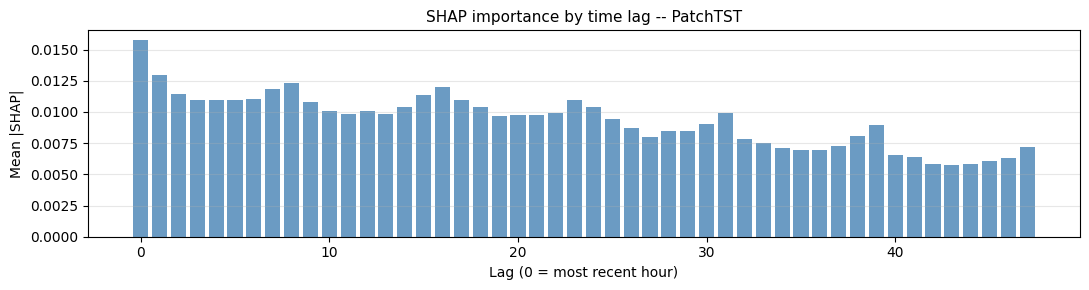

In [46]:
lag_importance = np.abs(shap_vals).mean(axis=(0, 2))

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(LOOKBACK), lag_importance[::-1], color="steelblue", alpha=0.8)
ax.set_xlabel("Lag (0 = most recent hour)")
ax.set_ylabel("Mean |SHAP|")
ax.set_title(f"SHAP importance by time lag -- {best_name}", fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

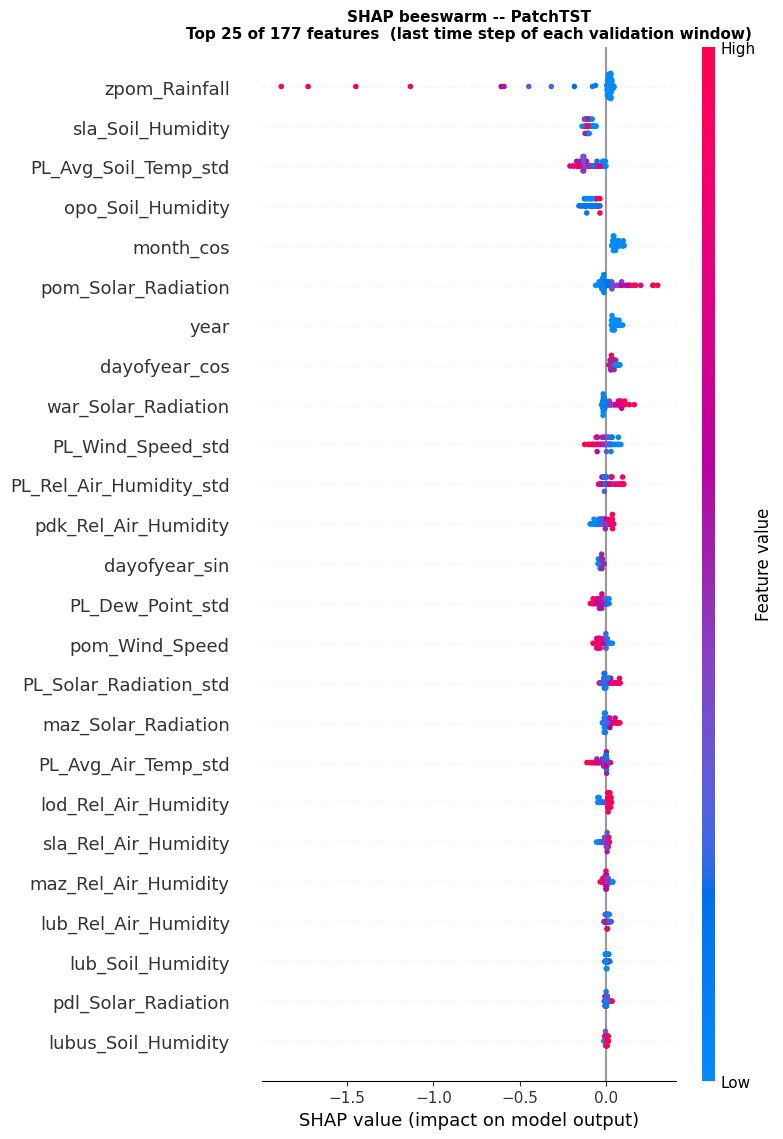

In [48]:
top_feat_names = feat_imp_df["feature"].head(SHAP_TOP_N).tolist()
top_feat_idx   = [MODEL_FEATURES.index(f) for f in top_feat_names]

shap_top = shap_vals[:, -1, top_feat_idx]          # (n_samples, SHAP_TOP_N)
X_top_bg = X_val_seq[:shap_vals.shape[0], -1, :][:, top_feat_idx]

shap.summary_plot(
    shap_top,
    features      = X_top_bg,
    feature_names = top_feat_names,
    max_display   = SHAP_TOP_N,
    plot_type     = "dot",
    show          = False,
)
plt.title(
    f"SHAP beeswarm -- {best_name}\n"
    f"Top {SHAP_TOP_N} of {len(MODEL_FEATURES)} features  (last time step of each validation window)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(); plt.show()

## 6. Feature importance -- LIME (local linear surrogate)

In [50]:
fixed_ctx = X_train_arr[-(LOOKBACK - 1):]   # (47, N_FEATURES)

interp_idx      = [MODEL_FEATURES.index(f) for f in INTERP_FEATURES if f in MODEL_FEATURES]
INTERP_FEAT_NAMES = [MODEL_FEATURES[i] for i in interp_idx]
n_interp = len(interp_idx)

def predict_for_lime(X_2d):
    full_X = np.zeros((len(X_2d), N_FEATURES), dtype="float32")
    full_X[:, interp_idx] = X_2d.astype("float32")
    seqs = np.tile(fixed_ctx[np.newaxis], (len(X_2d), 1, 1)).copy()
    seqs = np.concatenate([seqs, full_X[:, np.newaxis, :]], axis=1)
    with torch.no_grad():
        out = best_model(torch.FloatTensor(seqs).to(XAI_DEVICE)).cpu().numpy()
    return out.sum(axis=1)

lime_train_bg = X_train_arr[:, interp_idx]
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = lime_train_bg,
    feature_names = INTERP_FEAT_NAMES,
    mode          = "regression",
    random_state  = SEED,
)
print(f"LIME explainer ready with {n_interp} interpretable features.")

LIME explainer ready with 48 interpretable features.


In [20]:
pv_vals = val_df[TARGET].values
hours_v = val_df["hour"].values

peak_idx  = int(np.argmax(pv_vals))

noon_mask = (hours_v == 12) & (pv_vals > 0)
cloudy_idx = int(np.where(noon_mask)[0][np.argmin(pv_vals[noon_mask])]) if noon_mask.any() else 0

morning_mask = (hours_v >= 7) & (hours_v <= 9) & (pv_vals > 0.05 * pv_vals.max())
morning_idx  = int(morning_mask.nonzero()[0][0]) if morning_mask.any() else peak_idx

cases = [
    (peak_idx,    "Peak production",  "#FFC107"),
    (cloudy_idx,  "Cloudy noon",      "#607D8B"),
    (morning_idx, "Morning ramp-up",  "#4CAF50"),
]

print("Hours to explain:")
for idx, label, _ in cases:
    print(f"  {label:20s}  {val_df['Date'].iloc[idx]}  PV={pv_vals[idx]:.0f} MWh")

Hours to explain:
  Peak production       2026-05-10 12:00:00  PV=11682 MWh
  Cloudy noon           2026-05-07 12:00:00  PV=6282 MWh
  Morning ramp-up       2026-05-06 07:00:00  PV=4068 MWh


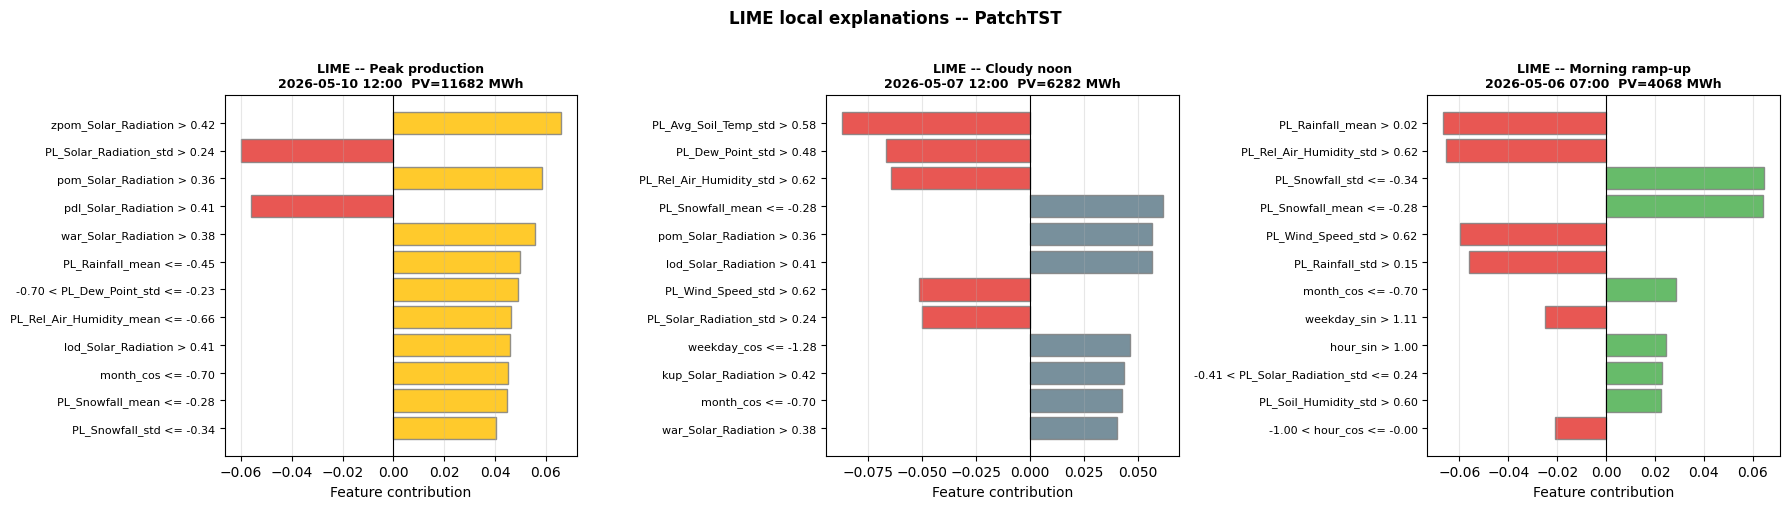

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (idx, label, color) in zip(axes, cases):
    x_current = X_val_arr[idx, interp_idx]
    exp = lime_explainer.explain_instance(
        x_current, predict_for_lime, num_features=12, num_samples=500,
    )
    feat_val_list = exp.as_list()
    feat_names_lime = [fv[0] for fv in feat_val_list]
    feat_vals_lime  = [fv[1] for fv in feat_val_list]
    bar_colors = [color if v > 0 else "#E53935" for v in feat_vals_lime]
    y_pos = list(range(len(feat_names_lime)))

    ax.barh(y_pos[::-1], feat_vals_lime, color=bar_colors, alpha=0.85, edgecolor="gray")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y_pos[::-1]); ax.set_yticklabels(feat_names_lime, fontsize=8)
    ax.set_title(
        f"LIME -- {label}\n{val_df['Date'].iloc[idx].strftime('%Y-%m-%d %H:%M')}  "
        f"PV={pv_vals[idx]:.0f} MWh",
        fontsize=9, fontweight="bold")
    ax.set_xlabel("Feature contribution"); ax.grid(alpha=0.3, axis="x")

plt.suptitle(f"LIME local explanations -- {best_name}", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## 7. SHAP vs LIME -- global ranking comparison

In [54]:
from collections import defaultdict

shap_imp_interp = (
    pd.DataFrame({
        "feature": INTERP_FEAT_NAMES,
        "shap": np.abs(shap_vals[:, :, interp_idx]).mean(axis=(0, 1))
    })
    .sort_values("shap", ascending=False)
    .reset_index(drop=True)
)

lime_agg = defaultdict(list)
for idx, _, _ in cases:
    x_current = X_val_arr[idx, interp_idx]
    exp = lime_explainer.explain_instance(
        x_current, predict_for_lime, num_features=n_interp, num_samples=300
    )
    for feat, val in exp.as_list():
        clean_name = feat.split(" ")[0]
        matched = [f for f in INTERP_FEAT_NAMES if f in feat]
        key = matched[0] if matched else clean_name
        lime_agg[key].append(abs(val))

lime_df = pd.DataFrame(
    [{"feature": k, "lime": np.mean(v)} for k, v in lime_agg.items()]
).sort_values("lime", ascending=False).reset_index(drop=True)

merged = (
    shap_imp_interp.merge(lime_df, on="feature", how="outer")
    .fillna(0)
    .sort_values("shap", ascending=False)
    .head(15)
)
merged["shap_rank"] = range(1, len(merged) + 1)
merged["lime_rank"] = merged["lime"].rank(ascending=False).astype(int)

merged[["feature", "shap", "shap_rank", "lime", "lime_rank"]]

,feature,shap,shap_rank,lime,lime_rank
3,PL_Avg_Soil_Temp_std,0.053810,1,0.033886,6
35,month_cos,0.045059,2,0.000000,13
1,PL_Avg_Air_Temp_std,0.032002,3,0.008191,10
9,PL_Rel_Air_Humidity_std,0.031264,4,0.044041,2
20,dayofyear_cos,0.031162,5,0.000000,13
15,PL_Solar_Radiation_std,0.030177,6,0.041284,4
17,PL_Wind_Speed_std,0.024777,7,0.035100,5
40,pom_Solar_Radiation,0.020097,8,0.031008,7
43,war_Solar_Radiation,0.018449,9,0.042238,3
5,PL_Dew_Point_std,0.016878,10,0.045426,1


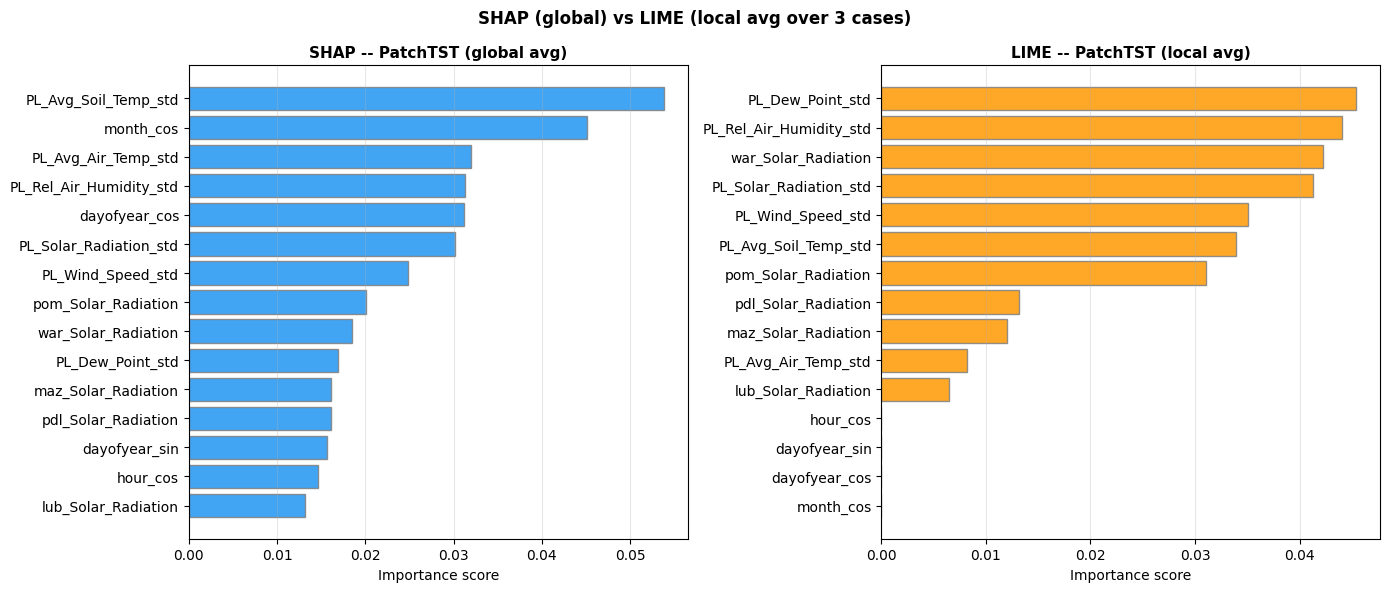

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top15 = merged.head(15)

for ax, col, label, color in [
    (axes[0], "shap", f"SHAP -- {best_name} (global avg)", "#2196F3"),
    (axes[1], "lime", f"LIME -- {best_name} (local avg)", "#FF9800"),
]:
    df_sorted = top15.sort_values(col)
    ax.barh(df_sorted["feature"], df_sorted[col], color=color, alpha=0.85, edgecolor="gray")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Importance score")
    ax.grid(alpha=0.3, axis="x")

plt.suptitle("SHAP (global) vs LIME (local avg over 3 cases)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()